#Netflix Content Library - Exploratory Data Analysis

##Overview

This notebook analyses Netflix's content catalogue (8,807 titles) to understand how the platform's library has grown, where content originates and what audience the platform primarily serves.

##Dataset

Source: Kaggle Netflix Movies and TV Shows(Shivan Bansal). Data covers titles available on Netflix up to the third quarter of 2021.

##Questions Explored

1. How has content volume and the Movies vs TV Shows split changed year over year?
2. Which Countries dominate Netflix's content catalogue and is the platform truly global?
3. What does the ratings distribution reveal about Netflix's primary target audience?

##Tools

Python . Pandas . Matplotlib . Jupyter Notebook

##Summary of Findings

Content Growth: Netflix's content library grew rapidly from 2015 to 2019, with 2019** representing the largest single-year addition of titles. The TV Show proportion increased and stayed stable over this period, suggesting astrategic shift toward series or a consistent dual-format strategy. The visible dip in 2020 t0 2021 likely reflects COVID-19 production disruptions rather than a change in strategy.

Geographical Distribution: The United States dominates Netflix's content library with 3,205 titles, 2,197 more than the second largest contributor. The top 3 countries account for approximately 57% of all content, confirming that despite Netflix's global presence, the content catalogue remains heavily concentrated in a small number of markets. India's significant presence reflects Netflix's aggressive expansion into the South Asian market from 2018 onwards.

Target Audience Adult-rated content(TV-MA','R','NC-17) accounts for approximately 46% of Netflix's catalogue, making it the dominant content tier by a significant margin. Kids and Family content combined represent only 23.3% of the titles, suggesting that Netflix's primary value proposition is adult entertainment rather than family-friendly programming. This has implications for how the platform competes against Disney+ and Apple TV+, which are more heavily weighted toward family content.

##Key Limitation

This dataset captures titles available for viewers and does not include viewership data. Content. Content volume is not a proxy to popularity, a country with few titles may still generate the majority of viewing hours.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
df = pd.read_csv(r'C:\Users\Angela\Documents\My SQL folder\Weekly Checkin\Netflix EDA\netflix_titles.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [3]:
print("shape", df.shape)

shape (8807, 12)


In [4]:
print("\ncolumns:", df.columns.tolist())


columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
for col in df.columns:
    n_unique = df[col].nunique()
    n_missing = df[col].isnull().sum()
    print(f"{col:25} unique: {n_unique:5}  missing: {n_missing}")

show_id                   unique:  8807  missing: 0
type                      unique:     2  missing: 0
title                     unique:  8807  missing: 0
director                  unique:  4528  missing: 2634
cast                      unique:  7692  missing: 825
country                   unique:   748  missing: 831
date_added                unique:  1767  missing: 10
release_year              unique:    74  missing: 0
rating                    unique:    17  missing: 4
duration                  unique:   220  missing: 3
listed_in                 unique:   514  missing: 0
description               unique:  8775  missing: 0


In [7]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [8]:
print("\nTypes:", df['type'].unique())
print("Rating sample:", df['rating'].unique()[:8])


Types: ['Movie' 'TV Show']
Rating sample: ['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R']


#Analysis Questions
Q1: Content Growth: How has the volume of content added to nexflix changed year over year, and is the movies vs.TV shows split shifting over time?
Q2: Geographic Distribution: Which countries produce the most netflix content, and is the platform genuinely global or still dominated by a few markets?
Q3: Content Ratings & Audience: What is the distribution of content ratings and what does that tell us about Netflix's primary target audience?

In [10]:
df.describe(include='object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [11]:
print(df['type'].value_counts())
print(df['type'].value_counts(normalize=True).round(3) * 100)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64
type
Movie      69.6
TV Show    30.4
Name: proportion, dtype: float64


In [13]:
# Date added is text,convert to string

df['date_added'] = pd.to_datetime(
    df['date_added'].str.strip(), format='mixed',
    errors='coerce' # rows that fail become NaT (not a time)
)

In [14]:
print(df['date_added'])

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8807, dtype: datetime64[ns]


In [16]:
# Extract year and month as separate columns
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [17]:
print(df['year_added'])
print(df['month_added'])

0       2021.0
1       2021.0
2       2021.0
3       2021.0
4       2021.0
         ...  
8802    2019.0
8803    2019.0
8804    2019.0
8805    2020.0
8806    2019.0
Name: year_added, Length: 8807, dtype: float64
0        9.0
1        9.0
2        9.0
3        9.0
4        9.0
        ... 
8802    11.0
8803     7.0
8804    11.0
8805     1.0
8806     3.0
Name: month_added, Length: 8807, dtype: float64


In [18]:
# How many rows lost their date?
print("NaT after conversion", df['date_added'].isnull().sum())

NaT after conversion 10


In [20]:
# Director; missing is acceptable for TV shows - 'fill with unknown'
df['director'] = df['director'].fillna('unknown')

In [21]:
print(df['director'])

0       Kirsten Johnson
1               unknown
2       Julien Leclercq
3               unknown
4               unknown
             ...       
8802      David Fincher
8803            unknown
8804    Ruben Fleischer
8805       Peter Hewitt
8806        Mozez Singh
Name: director, Length: 8807, dtype: object


In [22]:
# Country: missing affect finding the definite geographical distribution - fill with 'unknown'
df['country'] = df['country'].fillna('unknown')

In [23]:
print(df['country'])

0       United States
1        South Africa
2             unknown
3             unknown
4               India
            ...      
8802    United States
8803          unknown
8804    United States
8805    United States
8806            India
Name: country, Length: 8807, dtype: object


In [24]:
# Rating: small number missing - fill with 'Not Rated'
df['rating'] = df['rating'].fillna('Not Rated')
print(df['rating'])

0       PG-13
1       TV-MA
2       TV-MA
3       TV-MA
4       TV-MA
        ...  
8802        R
8803    TV-Y7
8804        R
8805       PG
8806    TV-14
Name: rating, Length: 8807, dtype: object


In [37]:
# Drop rows where date_added is missing
# (we need it to determine content growth year over year - only 10 rows affected)
df_dated = df.dropna(subset=['date_added']).copy()
print("Rows after dropping missingg dates:", len(df_dated))

Rows after dropping missingg dates: 8797


In [38]:
# Q1: Content Growth: How has the volume of content added to nexflix changed year over year, and is the movies vs.TV shows split shifting over time?
# Titles added per year - Movies vs TV Shows
yearly = df_dated.groupby(['year_added', 'type']).size().unstack(fill_value=0)
print(yearly)

type        Movie  TV Show
year_added                
2008.0          1        1
2009.0          2        0
2010.0          1        0
2011.0         13        0
2012.0          3        0
2013.0          6        5
2014.0         19        5
2015.0         56       26
2016.0        253      176
2017.0        839      349
2018.0       1237      412
2019.0       1424      592
2020.0       1284      595
2021.0        993      505


In [39]:
# What year had the most content added?
total_by_year = df_dated.groupby('year_added').size()
print("\nPeak year:", total_by_year.idxmax(),
     "with", total_by_year.max(), "titles")


Peak year: 2019.0 with 2016 titles


In [40]:
# TV Shows % per year - is it growing?
yearly['TV_pct'] = (yearly['TV Show'] /
                    (yearly['Movie'] + yearly['TV Show']) * 100).round(1)
print("\nTV Show % per year:\n", yearly[['TV Show','Movie','TV_pct']])


TV Show % per year:
 type        TV Show  Movie  TV_pct
year_added                        
2008.0            1      1    50.0
2009.0            0      2     0.0
2010.0            0      1     0.0
2011.0            0     13     0.0
2012.0            0      3     0.0
2013.0            5      6    45.5
2014.0            5     19    20.8
2015.0           26     56    31.7
2016.0          176    253    41.0
2017.0          349    839    29.4
2018.0          412   1237    25.0
2019.0          592   1424    29.4
2020.0          595   1284    31.7
2021.0          505    993    33.7


In [41]:
yearly['Movie_pct'] = (yearly['Movie'] /
                    (yearly['Movie'] + yearly['TV Show']) * 100).round(1)
print("\nMovie % per year:\n", yearly[['Movie','TV Show','Movie_pct']])


Movie % per year:
 type        Movie  TV Show  Movie_pct
year_added                           
2008.0          1        1       50.0
2009.0          2        0      100.0
2010.0          1        0      100.0
2011.0         13        0      100.0
2012.0          3        0      100.0
2013.0          6        5       54.5
2014.0         19        5       79.2
2015.0         56       26       68.3
2016.0        253      176       59.0
2017.0        839      349       70.6
2018.0       1237      412       75.0
2019.0       1424      592       70.6
2020.0       1284      595       68.3
2021.0        993      505       66.3


In [42]:
#Q2: Geographic Distribution: Which countries produce the most netflix content, and is the platform genuinely global or still dominated by a few markets?
df_dated['primary_country'] = df_dated['country'].str.split(',').str[0].str.strip()
print(df_dated['primary_country'])

0       United States
1        South Africa
2             unknown
3             unknown
4               India
            ...      
8802    United States
8803          unknown
8804    United States
8805    United States
8806            India
Name: primary_country, Length: 8797, dtype: object


In [44]:
# Top 15 countrie by title count
top_countries = (df_dated['primary_country'].value_counts().head(15))
print(top_countries)

primary_country
United States     3205
India             1008
unknown            830
United Kingdom     627
Canada             271
Japan              258
France             212
South Korea        211
Spain              181
Mexico             134
Australia          116
Egypt              112
Turkey             111
Germany            103
China              100
Name: count, dtype: int64


In [45]:
# What % of all content comes from the top 3 countries?
top3_pct = top_countries.head(3).sum()/ len(df_dated)* 100
print(f"\nTop 3 countries account for {top3_pct:.1f}% of all content")


Top 3 countries account for 57.3% of all content


In [47]:
# Movies vs TV Shows split per top countries
country_type = (df_dated[df_dated['primary_country']
               .isin(top_countries.head(8).index)]
               .groupby(['primary_country','type']).size().unstack(fill_value=0))
print(country_type)

type             Movie  TV Show
primary_country                
Canada             187       84
France             148       64
India              927       81
Japan               85      173
South Korea         47      164
United Kingdom     382      245
United States     2364      841
unknown            440      390


#Q3: Content Ratings & Audience: What is the distribution of content ratings and what does that tell us about Netflix's primary target audience?

In [48]:
# Overall ratings distribution
ratings = df['rating'].value_counts()
print(ratings)

rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
74 min          1
84 min          1
66 min          1
Name: count, dtype: int64


In [49]:
# Group ratings into audience tiers
adult_ratings = ['TV-MA','R','NC-17']
teen_ratings = ['TV-14','PG-13 ']
family_ratings = ['TV-PG','PG','TV-G','G']
kids_ratings = ['TV-Y7','TV-Y','TV-Y7-FV ']

df['audience'] = df['rating'].apply(lambda x:
    'Adult'  if x in adult_ratings  else
    'Teen'   if x in teen_ratings   else
    'Family' if x in family_ratings else
    'Kids'   if x in kids_ratings   else
    'Unknown'                               
)

audience_pct = df['audience'].value_counts(normalize=True)* 100
print(audience_pct.round(1))

audience
Adult      45.5
Teen       24.5
Family     16.0
Kids        7.3
Unknown     6.7
Name: proportion, dtype: float64


In [51]:
audience_list = []

for rating in df['rating']:
    if rating in ['TV-MA','R','NC-17']:
        audience_list.append('Adult')
    elif rating in ['TV-14','PG-13 ']:
        audience_list.append('Teen')
    elif rating in ['TV-PG','PG','TV-G','G']:
        audience_list.append('Family')
    elif rating in ['TV-Y7','TV-Y','TV-Y7-FV ']:
        audience_list.append('Kids')
    else:
        audience_list.append('Unknown')
df['audience'] = audience_list

audience_pct = df['audience'].value_counts(normalize=True) * 100
print(audience_pct.round(1))

audience
Adult      45.5
Teen       24.5
Family     16.0
Kids        7.3
Unknown     6.7
Name: proportion, dtype: float64


In [52]:
audience_list = []

for rating in df['rating']:
    if rating in adult_ratings:
        audience_list.append('Adult')
    elif rating in teen_ratings:
        audience_list.append('Teen')
    elif rating in family_ratings:
        audience_list.append('Family')
    elif rating in kids_ratings:
        audience_list.append('Kids')
    else:
        audience_list.append('Unknown')
df['audience'] = audience_list

audience_pct = df['audience'].value_counts(normalize=True) * 100
print(audience_pct.round(1))

audience
Adult      45.5
Teen       24.5
Family     16.0
Kids        7.3
Unknown     6.7
Name: proportion, dtype: float64


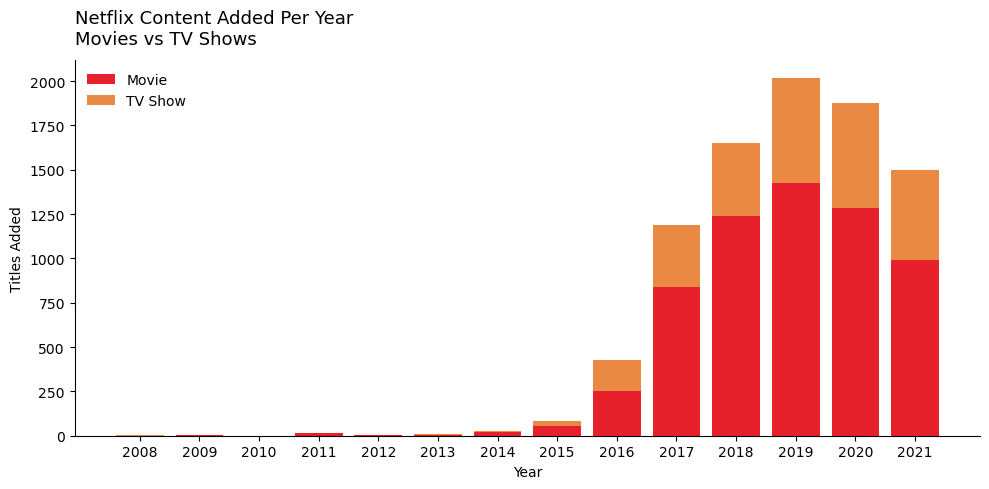

In [54]:
#Q1 Content Growth

fig, ax = plt.subplots(figsize=(10,5))

years = yearly.index
movies = yearly['Movie']
shows = yearly['TV Show']

ax.bar(years, movies, label='Movie', color='#e50914', alpha=0.9)
ax.bar(years, shows, label='TV Show', color='#e87c2f', alpha=0.9, bottom=movies)

ax.set_title('Netflix Content Added Per Year\nMovies vs TV Shows',
            fontsize=13, pad=12, loc='left')
ax.set_xlabel('Year')
ax.set_ylabel('Titles Added')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(years)
plt.tight_layout()
plt.show()

###Finding 1 - Content Growth
Netflix's content library grew rapidly from 2015 to 2019, with 2019** representing the largest single-year addition of titles. 
The TV Show proportion increased and stayed stable over this period, suggesting astrategic shift toward series or a consistent dual-format
strategy. The visible dip in 2020 t0 2021 likely reflects COVID-19 production disruptions rather than a change in strategy.

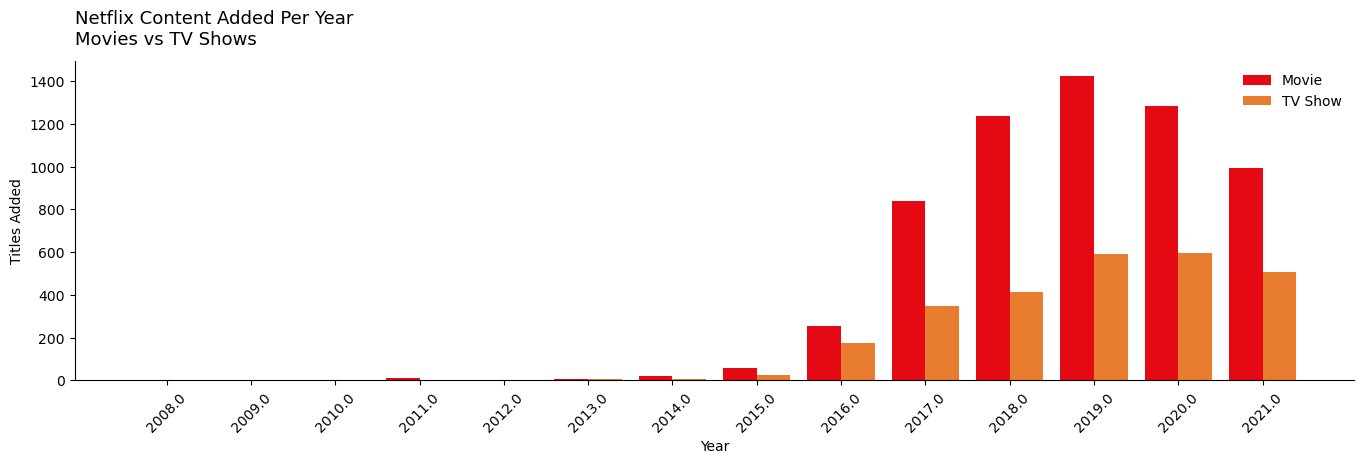

In [61]:

fig, ax = plt.subplots(figsize=(14,5))

years = yearly.index
movies = yearly['Movie']
shows = yearly['TV Show']

x = range(len(years))
width = 0.4

ax.bar([i - width/2 for i in x], movies, width=width, label='Movie', color='#e50914')
ax.bar([i + width/2 for i in x], shows, width=width, label='TV Show', color='#e87c2f')

ax.set_title('Netflix Content Added Per Year\nMovies vs TV Shows',
            fontsize=13, pad=12, loc='left')
ax.set_xlabel('Year')
ax.set_ylabel('Titles Added')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45)
plt.tight_layout(pad=2)
plt.show()

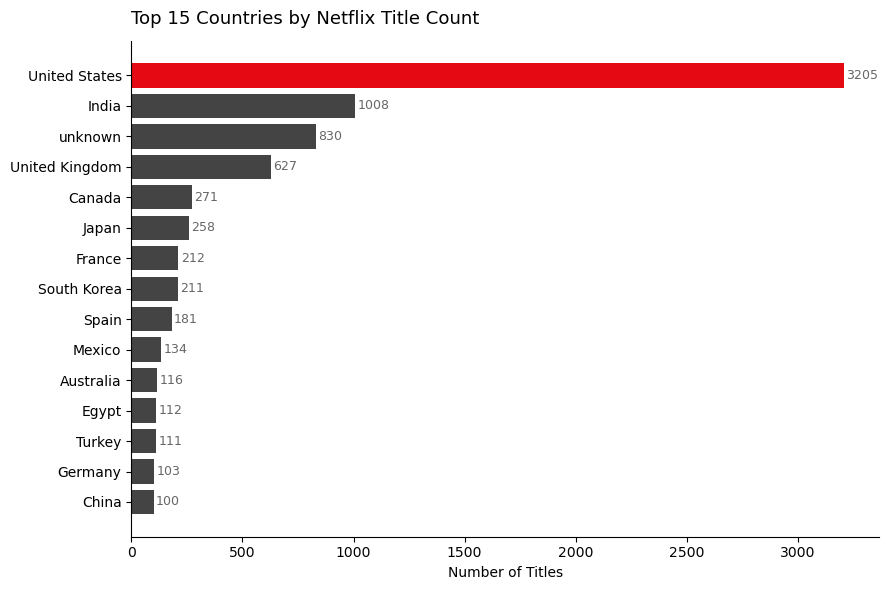

In [63]:
#Q2 Top Countries

top15 = (df_dated['primary_country'].value_counts().head(15).sort_values())

fig, ax = plt.subplots(figsize=(9,6))

colors = ['#e50914' if c == top15.index[-1]
         else '#444' for c in top15.index]

ax.barh(top15.index, top15.values, color=colors)
ax.set_title('Top 15 Countries by Netflix Title Count',
            fontsize=13, pad=12, loc='left')
ax.set_xlabel('Number of Titles')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, v in enumerate(top15.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=9, color='#666')

plt.tight_layout()
plt.show()

###Finding2: Geographical Distribution
The United States dominates Netflix's content library with 3,205 titles, 2,197 more than the second largest contributor. The top 3 countries
account for approximately 57% of all content, confirming that despite Netflix's global presence, the content catalogue remains heavily concentrated
in a small number of markets. India's significant presence reflects Netflix's aggressive expansion into the South Asian market from 2018 onwards.

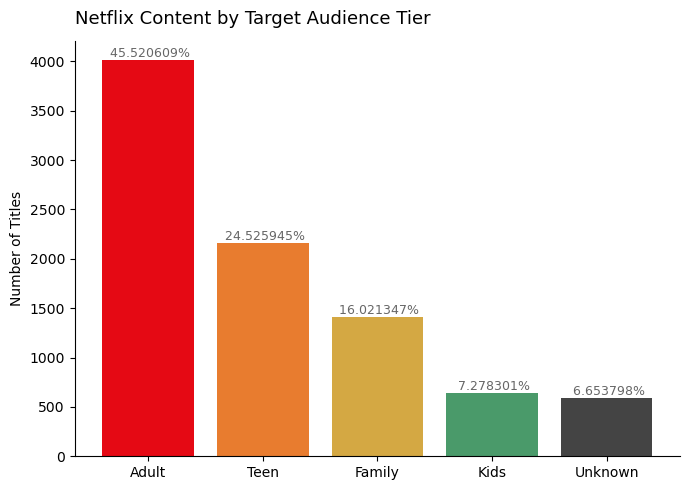

In [68]:
#Q3: Audience Ratings
audience_counts = df['audience'].value_counts()

fig, ax = plt.subplots(figsize=(7,5))

palette = {
    'Adult': '#e50914',
    'Teen':  '#e87c2f',
    'Family':'#d4a843',
    'Kids':  '#4a9a6a',
    'Unknown':'#444'
}
bar_colors = [palette.get(i, '#888') for i in audience_counts.index]

ax.bar(audience_counts.index, audience_counts.values, color=bar_colors)
ax.set_title('Netflix Content by Target Audience Tier',
            fontsize=13, pad=12, loc='left')
ax.set_ylabel('Number of Titles')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

total = audience_counts.sum()
for i, (label, count) in enumerate(audience_counts.items()):
    ax.text(i, count + 30, f'{count/total*100: 1f}%',
           ha='center', fontsize=9, color='#666')

plt.tight_layout()
plt.show()

###Finding 3 Target Audience
Adult-rated content(TV-MA','R','NC-17) accounts for approximately 46% of Netflix's catalogue, making it the dominant content tier by a significant
margin. Kids and Family content combined represent only 23.3% of the titles, suggesting that Netflix's primary value proposition is adult 
entertainment rather than family-friendly programming. This has implications for how the platform competes against Disney+ and Apple TV+, which are
more heavily weighted toward family content.